# Projet Compression d'Image

Le but de ce projet est de se familiariser avec la manipulation des images avec Python, notamment en utilisant des librairies spécialisées mais aussi en implémentant des méthodes mathématiques sur les images.

Il convient alors de considérer le paradigme de l'imagerie dans le sens des ordinateurs, à savoir une fonction de l'espace, supposée continue mais en réalité discrète.

Nous allons compresser une image et pour cela implémenter la transformée de Fourier pour décomposer notre signal.

## Librairies et Data

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

In [6]:
def im_show(img, title="Result"):
    plt.figure(figsize=(10, 8))
    
    # Cas 1 : Image en niveaux de gris (Matrice 2D)
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
        
    # Cas 2 : Image couleur (Tenseur 3D)
    else:
        # On passe de BGR (OpenCV) à RGB (Matplotlib)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        
    plt.title(title)
    plt.axis('off')
    plt.show()

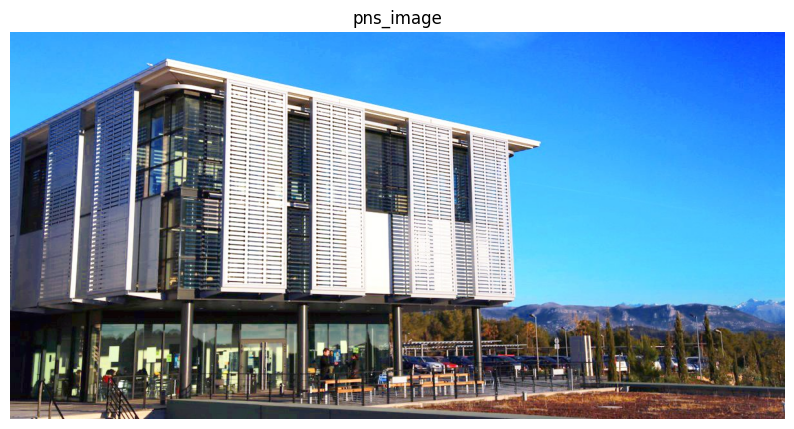

In [14]:
img = cv2.imread("../data/pns_original.png")
im_show(img, "pns_image")

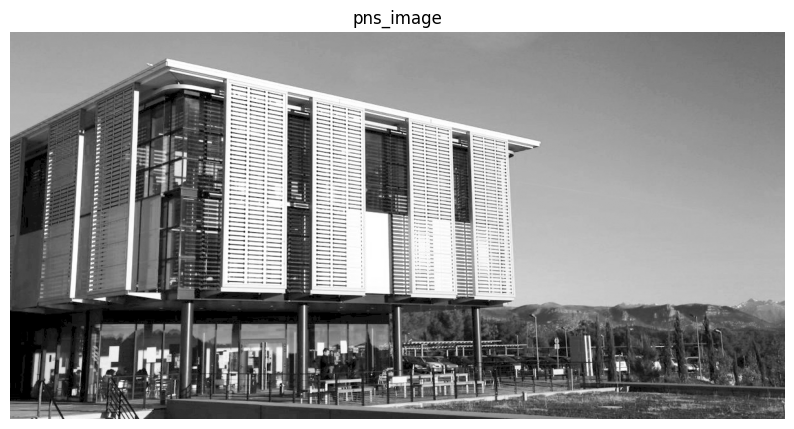

In [15]:
img = cv2.imread("../data/pns_original.png", 0)
im_show(img, "pns_image")

In [16]:
print(img)

[[159 159 159 ... 105 106 107]
 [159 159 159 ... 105 105 106]
 [159 159 159 ... 105 106 106]
 ...
 [133 135 134 ...  66  74  95]
 [144 143 142 ...  68  72  85]
 [144 148 151 ...  84  82  90]]


In [18]:
img.shape

(600, 1200)

In [75]:
def trunc_1D(img, new_x, new_y):
    s = img.shape
    return img[:new_x,:new_y]

def trunc(img, size=8):
    s = img.shape
    new_x = s[0]-s[0]%size
    new_y = s[1]-s[1]%size

    #Si l'image n'a qu'une seule couleur
    if len(s) == 2 : return trunc_1D(img, new_x, new_y)
    
    # Pour s'assurer de ne pas avoir d'erreur d'array
    res = np.zeros((new_x, new_y, s[2]))
    for i in range(res.shape[2]):
        res[:, :, i] = trunc_1D(img[:, :, i], new_x, new_y)

    return res

In [76]:
img_RGB = cv2.imread("../data/pns_original.png")
img_RGB.shape

(600, 1200, 3)

In [77]:
img_tr = trunc(img=img_RGB[:-1, :, :])
img_tr.shape

(592, 1200, 3)

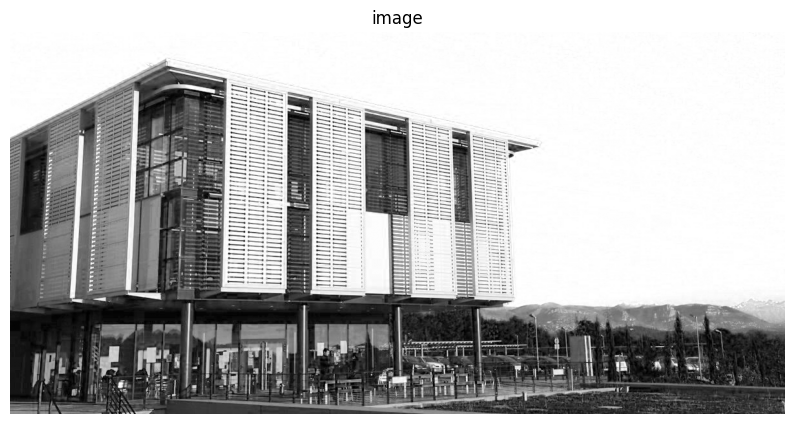

In [78]:
im_show(img_tr[:, :, 0], "image")

Nous réaliserons d'abord toutes les transformations en 1D, puis nous généraliserons (en adaptant bien sûr en vectoriel et non pas juste une boucle)

In [116]:
img_tr = trunc(img)
def centrage(img):
    return img-128*np.ones(img.shape)

img_tr = centrage(img_tr)
img_tr

array([[ 31.,  31.,  31., ..., -23., -22., -21.],
       [ 31.,  31.,  31., ..., -23., -23., -22.],
       [ 31.,  31.,  31., ..., -23., -22., -22.],
       ...,
       [  5.,   7.,   6., ..., -62., -54., -33.],
       [ 16.,  15.,  14., ..., -60., -56., -43.],
       [ 16.,  20.,  23., ..., -44., -46., -38.]], shape=(600, 1200))

In [80]:
Q = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
])

En prenant la formule donnée, on peut déterminer que D (résultat de la DCT-II) s'apparente à un changement de base.

Il nous faut donc déterminer cette matrice P changement de base, qui s'applique à la formule D = PMPt

In [82]:
Px, Py = 8, 8
P = np.zeros((Px, Py))
for k in range(Px):
    for i in range(Py):
        Ck = 1/np.sqrt(2) if k == 0 else 1
        P[k, i] = np.sqrt(1/4) * Ck * np.cos(((2*i + 1)*k*np.pi)/16)

P

array([[ 0.35355339,  0.35355339,  0.35355339,  0.35355339,  0.35355339,
         0.35355339,  0.35355339,  0.35355339],
       [ 0.49039264,  0.41573481,  0.27778512,  0.09754516, -0.09754516,
        -0.27778512, -0.41573481, -0.49039264],
       [ 0.46193977,  0.19134172, -0.19134172, -0.46193977, -0.46193977,
        -0.19134172,  0.19134172,  0.46193977],
       [ 0.41573481, -0.09754516, -0.49039264, -0.27778512,  0.27778512,
         0.49039264,  0.09754516, -0.41573481],
       [ 0.35355339, -0.35355339, -0.35355339,  0.35355339,  0.35355339,
        -0.35355339, -0.35355339,  0.35355339],
       [ 0.27778512, -0.49039264,  0.09754516,  0.41573481, -0.41573481,
        -0.09754516,  0.49039264, -0.27778512],
       [ 0.19134172, -0.46193977,  0.46193977, -0.19134172, -0.19134172,
         0.46193977, -0.46193977,  0.19134172],
       [ 0.09754516, -0.27778512,  0.41573481, -0.49039264,  0.49039264,
        -0.41573481,  0.27778512, -0.09754516]])

Pour pouvoir plus tard appliquer ma fonction de manière vectorielle, je vais créer un tableau qui regroupera tous les blocs de 8, bien indexés pour refaire l'image.

De fait, je pourrai d'abord tester mon algo sur n'importe quel bloc pour faire les tests puis, appliquer sur chaque bloc directement mon algo.

In [117]:
s_tr = img_tr.shape
n_brows = s_tr[0]//8 #nb de lignes de blocs
n_bcols = s_tr[1]//8 #nb de colonnes de blocs

In [118]:
# Accéder à n'importe quel bloc :
i_b = 2 #indice ligne
y_b = 2 #indice colonne
img_tr[i_b*8:(i_b+1)*8, y_b*8:(y_b+1)*8]

array([[32., 32., 32., 32., 32., 32., 32., 32.],
       [32., 32., 32., 32., 32., 32., 32., 32.],
       [32., 32., 32., 32., 32., 32., 32., 32.],
       [32., 32., 32., 32., 32., 32., 32., 32.],
       [34., 34., 34., 34., 34., 34., 34., 34.],
       [34., 34., 34., 34., 34., 34., 34., 34.],
       [34., 35., 35., 34., 34., 34., 34., 34.],
       [34., 35., 35., 35., 34., 34., 34., 34.]])

In [119]:
# Ainsi la nouvelle matrice :
img_bloc = np.zeros((n_brows, n_bcols, 8, 8))
for row in range(n_brows):
    for col in range(n_bcols):
        img_bloc[row, col] = img_tr[row*8:(row+1)*8, col*8:(col+1)*8]

img_bloc

array([[[[ 31.,  31.,  31., ...,  31.,  31.,  31.],
         [ 31.,  31.,  31., ...,  32.,  32.,  32.],
         [ 31.,  31.,  31., ...,  31.,  31.,  31.],
         ...,
         [ 31.,  31.,  31., ...,  31.,  31.,  31.],
         [ 30.,  30.,  30., ...,  32.,  32.,  32.],
         [ 31.,  31.,  31., ...,  31.,  31.,  31.]],

        [[ 32.,  32.,  31., ...,  29.,  29.,  29.],
         [ 32.,  32.,  31., ...,  31.,  29.,  29.],
         [ 32.,  31.,  31., ...,  31.,  31.,  31.],
         ...,
         [ 31.,  31.,  31., ...,  32.,  32.,  32.],
         [ 31.,  31.,  31., ...,  31.,  31.,  31.],
         [ 32.,  31.,  31., ...,  31.,  31.,  31.]],

        [[ 30.,  30.,  30., ...,  31.,  31.,  31.],
         [ 29.,  29.,  30., ...,  31.,  32.,  32.],
         [ 29.,  29.,  30., ...,  32.,  32.,  32.],
         ...,
         [ 32.,  32.,  32., ...,  30.,  30.,  30.],
         [ 32.,  32.,  32., ...,  31.,  30.,  30.],
         [ 32.,  32.,  32., ...,  31.,  31.,  31.]],

        ...,

  

Le but serait de ne pas utiliser de boucle... Je vais chercher un moyen mais n'ai pas d'idées pour le moment

In [120]:
row = np.arange(n_brows)
col = np.arange(n_bcols)

row

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74])

In [121]:
img_bloc[row, col] = img_tr[row*8:(row+1)*8, col*8:(col+1)*8]

TypeError: only integer scalar arrays can be converted to a scalar index

Finalement, je me rends compte que ça ne sert à rien de créer cette matrice sans boucle. En fait, ça ne sert à rien de créer cette matrice tout court.

Il faut simplement appliquer la suite du traitement sur chaque bloc, et remplir la matrice finale. Ce sera le traitement le plus optimisé.

In [122]:
for row in range(n_brows):
    for col in range(n_bcols):
        img_bloc[row, col] = img_tr[row*8:(row+1)*8, col*8:(col+1)*8]

In [123]:
#Prenons un bloc au hasard
i=34
y=12
bloc = img_bloc[i, y]

bloc

array([[ -44.,  -41.,  -35.,  -32.,  -10.,   92.,  126.,  124.],
       [ -44.,  -46.,  -33.,  -23.,   -2.,   95.,  126.,  122.],
       [ -30.,  -48.,  -41.,  -26.,   -2.,   95.,  126.,  121.],
       [ -44.,  -72.,  -60.,  -33.,    0.,  100.,  127.,  121.],
       [ -85., -100.,  -69.,  -32.,   10.,  110.,  127.,  125.],
       [ -89.,  -89.,  -56.,  -26.,   16.,  114.,  126.,  126.],
       [ -60.,  -62.,  -41.,  -30.,   14.,  117.,  124.,  126.],
       [ -41.,  -46.,  -41.,  -38.,   16.,  126.,  126.,  123.]])

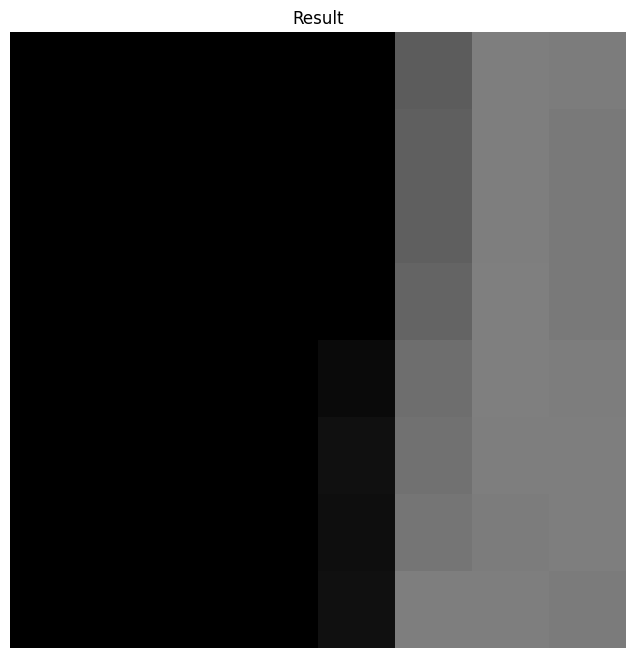

In [124]:
im_show(bloc)

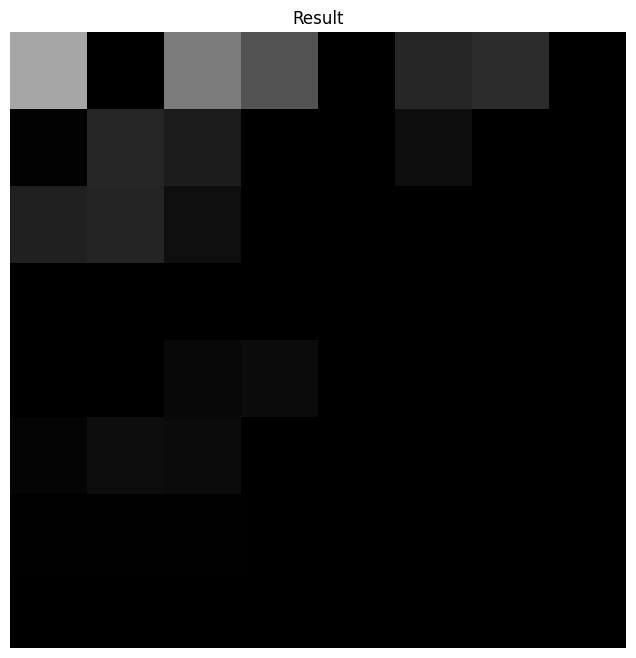

In [126]:
# Appliquons le traitement de l'image
D = P@bloc@np.transpose(P)
im_show(D)

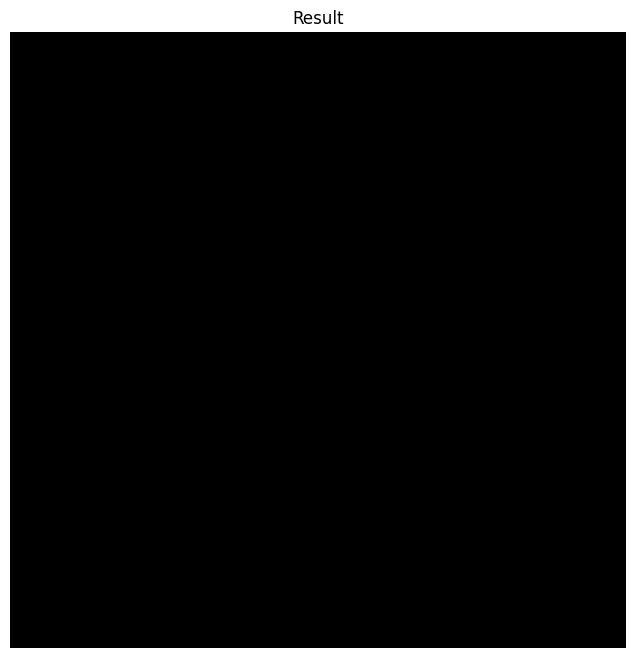

In [130]:
D = D//Q
im_show(D)

In [131]:
D

array([[ 0., -1.,  0.,  0., -1.,  0.,  0., -1.],
       [ 0.,  0.,  0., -1., -1.,  0., -1., -1.],
       [ 0.,  0.,  0., -1., -1., -1.,  0., -1.],
       [-1., -1., -1., -1.,  0., -1.,  0., -1.],
       [-1., -1.,  0.,  0.,  0., -1.,  0., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  0.],
       [ 0.,  0.,  0.,  0., -1., -1., -1., -1.],
       [-1., -1.,  0., -1.,  0., -1.,  0.,  0.]])

In [ ]:
# Ainsi de manière bourrine
img_compressed = np.zeros_like(img_tr)
for row in range(n_brows):
    for col in range(n_bcols):
        img_compressed[row*8:(row+1)*8, col*8:(col+1)*8] = img_tr[row*8:(row+1)*8, col*8:(col+1)*8]